# Cross platform robustness analysis on shared Xenium gene panel

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os
from scipy.stats import spearmanr
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')
import MacSGP

RAW_PATH = "/import/home2/share/yqzeng/data/CRC"
DATA_PATH = "/import/home2/share/yqzeng/MacSGP/data/CRC"
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/results/CRC/visium_hd_16um_xenium_panel"
os.makedirs(SAVE_PATH, exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
# Nature Communications style
mpl.rcParams.update({
    'font.family'       : 'Helvetica',
    'font.size'         : 7,
    'axes.titlesize'    : 8,
    'axes.labelsize'    : 7,
    'xtick.labelsize'   : 6.5,
    'ytick.labelsize'   : 6.5,
    'axes.linewidth'    : 0.5,
    'xtick.major.width' : 0.5,
    'ytick.major.width' : 0.5,
    'xtick.major.size'  : 2.5,
    'ytick.major.size'  : 2.5,
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'savefig.dpi'       : 150,
    'figure.dpi'        : 75,
})

In [3]:
adata_xenium = sc.read_h5ad(os.path.join("/home/yzengbj/my_project/results/CRC", "adata_xenium_filtered_10_18.h5ad"))
adata_visium = sc.read_h5ad('/import/home2/share/yqzeng/MacSGP/results/CRC/visium_xenium_panel/adata_result.h5ad')
adata_result = sc.read_h5ad(os.path.join(SAVE_PATH, "adata_result_0.06_new.h5ad"))

In [4]:
loading_hd = adata_result.varm['loading']
loading_visium = adata_visium.varm['loading']
loading_xenium = adata_xenium.varm['loading']

In [5]:
# Shared genes and cell types across all three datasets
shared_genes = loading_hd.index.intersection(loading_visium.index).intersection(loading_xenium.index)
shared_ct    = loading_hd.columns.intersection(loading_visium.columns).intersection(loading_xenium.columns)
print(f'Shared genes: {len(shared_genes)},  Shared cell types: {len(shared_ct)}')

lh = loading_hd.loc[shared_genes, shared_ct]
lv = loading_visium.loc[shared_genes, shared_ct]
lx = loading_xenium.loc[shared_genes, shared_ct]

Shared genes: 407,  Shared cell types: 21


In [6]:
# Pairwise |Pearson r| for each cell type, sign-aligned before taking abs
pairs = {
    'Xenium vs HD 16um': (lx, lh),
    'Xenium vs Visium':  (lx, lv),
    'HD 16um vs Visium': (lh, lv),
}

corr_df = pd.DataFrame(index=shared_ct, columns=list(pairs.keys()), dtype=float)

for label, (la, lb) in pairs.items():
    for ct in shared_ct:
        r, _ = pearsonr(la[ct], lb[ct])
        corr_df.loc[ct, label] = abs(r)

# Sort by mean correlation across pairs
corr_df = corr_df.loc[corr_df.mean(axis=1).sort_values(ascending=False).index]
corr_df

,Xenium vs HD 16um,Xenium vs Visium,HD 16um vs Visium
Tumor III,0.868742,0.841084,0.908684
Macrophage,0.887320,0.788619,0.890272
mRegDC,0.833024,0.789705,0.858343
Enterocyte,0.799343,0.709048,0.907030
Endothelial,0.726912,0.723154,0.913241
Tumor V,0.814531,0.659404,0.833426
Goblet,0.825536,0.604849,0.773838
Plasma,0.606653,0.703282,0.810099
Pericytes,0.904299,0.429829,0.687274
CD8 T cell,0.465561,0.317837,0.862154


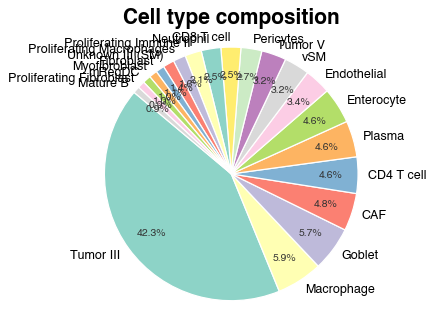

In [7]:
# ============================================================
# Pie chart of cell type proportions (publication style)
# ============================================================
ct_plot = corr_df.index
proportions = adata_xenium.obsm['proportion'][ct_plot].mean().sort_values(ascending=False)
palette = sns.color_palette('Set3', n_colors=len(proportions))

fig, ax = plt.subplots(figsize=(4.8, 4.8))

wedges, texts, autotexts = ax.pie(
    proportions,
    labels=proportions.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=palette,
    pctdistance=0.78,
    labeldistance=1.08,
    wedgeprops=dict(edgecolor='white', linewidth=1.2),
    textprops=dict(fontsize=12),
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_color('#333333')
    #at.set_fontfamily('')

ax.set_title('Cell type composition', fontsize=20,
             fontweight='bold', pad=12) #fontfamily='Arial')
ax.axis('equal')

# plt.savefig('cell_type_proportions.pdf', bbox_inches='tight', pad_inches=0.05)
# plt.savefig('cell_type_proportions.png', bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

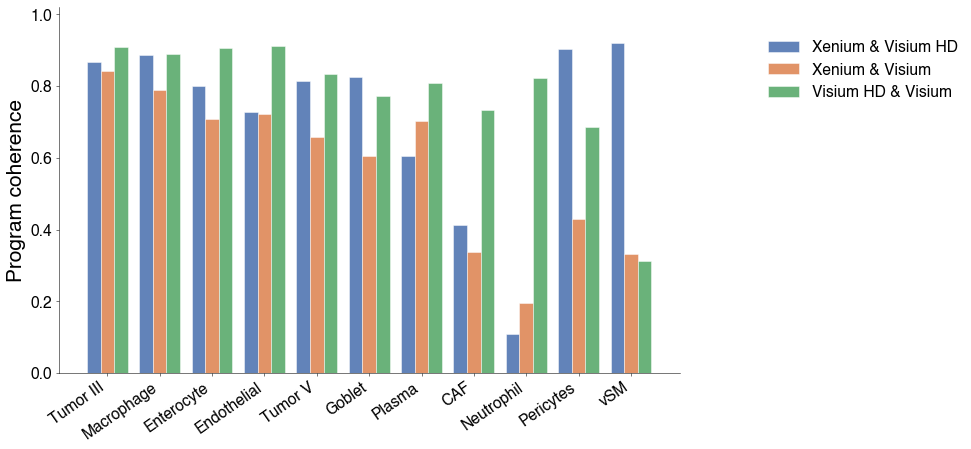

In [8]:
import matplotlib.pyplot as plt
ct_plot = [   'CAF', 'Enterocyte', 'Endothelial', 'Goblet', 'Macrophage',
    'Neutrophil', 'Pericytes', 
    'Plasma', #'Proliferating Macrophages',
    'Proliferating Fibroblast',
    'Tumor III', 'Tumor V', 'vSM',]

ct_plot = [
    # Pattern A: consistently high
    "Tumor III", "Macrophage", "Enterocyte", "Endothelial", "Tumor V",
    # Pattern B: Xenium panel limitation
    "Goblet", "Plasma", "CAF", "Neutrophil",
    # Pattern C: Visium resolution limitation
    "Pericytes", "vSM",
    # Pattern D: rare cell type
    #"Proliferating Fibroblast",
]
# ── Bar plot ──────────────────────────────────────────────────────────────────
plot_df = corr_df.loc[ct_plot]
n_ct    = len(ct_plot)
x       = np.arange(n_ct)
width   = 0.26
colors  = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(max(6, n_ct * 1.2), 6))

for i, (label, color) in enumerate(zip(pairs.keys(), colors)):
    offset = (i - 1) * width
    ax.bar(x + offset, plot_df[label], width, label=label,
           color=color, edgecolor='white', linewidth=0.5, alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(ct_plot, rotation=35, ha='right', fontsize=15)
ax.set_ylabel('Program coherence', fontsize=20)
#ax.set_title('Cross-platform loading consistency (Xenium gene panel)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.02)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=15)
#ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(frameon=False, fontsize=15, bbox_to_anchor=(1.12, 0.95), labels=['Xenium & Visium HD', 'Xenium & Visium', 'Visium HD & Visium'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/loading_correlation_barplot.pdf', bbox_inches='tight')
plt.show()

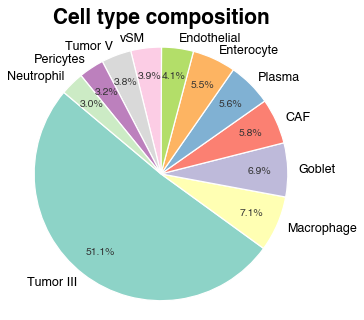

In [9]:
proportions = adata_xenium.obsm['proportion'][ct_plot].mean().sort_values(ascending=False)
palette = sns.color_palette('Set3', n_colors=len(proportions))

fig, ax = plt.subplots(figsize=(4.8, 4.8))

wedges, texts, autotexts = ax.pie(
    proportions,
    labels=proportions.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=palette,
    pctdistance=0.78,
    labeldistance=1.08,
    wedgeprops=dict(edgecolor='white', linewidth=1.2),
    textprops=dict(fontsize=12),
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_color('#333333')
    #at.set_fontfamily('')

ax.set_title('Cell type composition', fontsize=20,
             fontweight='bold', pad=12) #fontfamily='Arial')
ax.axis('equal')

# plt.savefig('cell_type_proportions.pdf', bbox_inches='tight', pad_inches=0.05)
# plt.savefig('cell_type_proportions.png', bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

In [10]:
from sklearn.decomposition import NMF
import scipy.sparse

n_components = 11

# Align gene order to shared_genes, use log-normalized expression (adata.X)
def get_expr_matrix(adata, genes):
    idx = [list(adata.var_names).index(g) for g in genes]
    X = adata.X[:, idx]
    if scipy.sparse.issparse(X):
        X = X.toarray()
    return X.astype(float)

X_xenium = get_expr_matrix(adata_xenium, shared_genes)
X_hd     = get_expr_matrix(adata_result,  shared_genes)
X_visium = get_expr_matrix(adata_visium,  shared_genes)

print(f'Xenium : {X_xenium.shape},  min={X_xenium.min():.2f}')
print(f'HD 16um: {X_hd.shape},  min={X_hd.min():.2f}')
print(f'Visium : {X_visium.shape},  min={X_visium.min():.2f}')

Xenium : (326460, 407),  min=0.00
HD 16um: (137051, 407),  min=0.00
Visium : (4269, 407),  min=0.00


In [11]:
# Run NMF on each platform (Xenium may take ~1-2 min)
nmf_kws = dict(n_components=n_components, random_state=42, max_iter=500, init='nndsvda')

nmf_xenium = NMF(**nmf_kws)
W_xenium = nmf_xenium.fit_transform(X_xenium)   # spots × k
H_xenium = pd.DataFrame(nmf_xenium.components_, columns=shared_genes,
                         index=[f'NMF{i+1}' for i in range(n_components)])

nmf_hd = NMF(**nmf_kws)
W_hd = nmf_hd.fit_transform(X_hd)
H_hd = pd.DataFrame(nmf_hd.components_, columns=shared_genes,
                     index=[f'NMF{i+1}' for i in range(n_components)])

nmf_visium = NMF(**nmf_kws)
W_visium = nmf_visium.fit_transform(X_visium)
H_visium = pd.DataFrame(nmf_visium.components_, columns=shared_genes,
                         index=[f'NMF{i+1}' for i in range(n_components)])

print('NMF done.')

NMF done.


In [12]:
from scipy.optimize import linear_sum_assignment

def best_match_corr(Ha, Hb):
    """Return correlation matrix and optimal row assignment (maximize |r|)."""
    n = len(Ha)
    C = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            r, _ = pearsonr(Ha.iloc[i], Hb.iloc[j])
            C[i, j] = abs(r)
    row_ind, col_ind = linear_sum_assignment(-C)   # maximise
    return C, row_ind, col_ind

In [13]:
MOFA_PATH = '/import/home2/share/yqzeng/MacSGP/results/CRC/mofa_xenium_panel'

W_mofa_xenium = pd.read_csv(f'{MOFA_PATH}/weights_xenium.csv',  index_col=0)
W_mofa_hd     = pd.read_csv(f'{MOFA_PATH}/weights_hd_16um.csv', index_col=0)
W_mofa_visium = pd.read_csv(f'{MOFA_PATH}/weights_visium.csv',  index_col=0)

# Align to shared genes
mofa_genes = (W_mofa_xenium.index
              .intersection(W_mofa_hd.index)
              .intersection(W_mofa_visium.index))
W_mofa_xenium = W_mofa_xenium.loc[mofa_genes].iloc[:, 0:11]
W_mofa_hd     = W_mofa_hd.loc[mofa_genes].iloc[:, 0:11]
W_mofa_visium = W_mofa_visium.loc[mofa_genes].iloc[:, 0:11]

print(f'MOFA weights — genes: {len(mofa_genes)}, factors: {W_mofa_xenium.shape[1]}')

MOFA weights — genes: 407, factors: 11


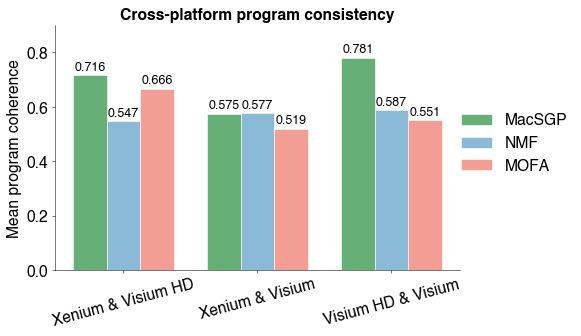

In [14]:
# Compare mean |Pearson r| across platforms: MacSGP vs NMF vs MOFA
# MacSGP: direct correspondence by cell type name, use mean |r| over shared_ct
# NMF / MOFA: no label correspondence, use Hungarian-matched mean |r|

pair_labels = ['Xenium vs HD 16um', 'Xenium vs Visium', 'HD 16um vs Visium']

# MacSGP — direct per-cell-type correlation, averaged over shared cell types
macsgp_mean_r = corr_df.loc[ct_plot].mean(axis=0)[pair_labels].tolist()

# NMF & MOFA — Hungarian matching
hungarian_pairs = {
    'NMF': [
        (H_xenium,        H_hd),
        (H_xenium,        H_visium),
        (H_hd,            H_visium),
    ],
    'MOFA': [
        (W_mofa_xenium.T, W_mofa_hd.T),
        (W_mofa_xenium.T, W_mofa_visium.T),
        (W_mofa_hd.T,     W_mofa_visium.T),
    ],
}

hungarian_mean_r = {}
for method, pairs in hungarian_pairs.items():
    vals = []
    for Ha, Hb in pairs:
        C, row_ind, col_ind = best_match_corr(Ha, Hb)
        vals.append(np.mean([C[i, col_ind[i]] for i in row_ind]))
    hungarian_mean_r[method] = vals

mean_r = {'MacSGP': macsgp_mean_r, **hungarian_mean_r}

# ── Bar plot ──────────────────────────────────────────────────────────────────
x         = np.arange(len(pair_labels))
n_methods = len(mean_r)
width     = 0.25
colors_method = {'MacSGP': '#55A868', 'NMF': '#7FB3D3', 'MOFA': '#F1948A'}

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, (method, color) in enumerate(colors_method.items()):
    offset = (i - (n_methods - 1) / 2) * width
    bars = ax.bar(x + offset, mean_r[method], width, label=method,
                  color=color, edgecolor='white', linewidth=0.6, alpha=0.9)
    for bar, val in zip(bars, mean_r[method]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(['Xenium & Visium HD', 'Xenium & Visium', 'Visium HD & Visium'], rotation=15, ha='center', fontsize=15)
ax.set_ylabel('Mean program coherence', fontsize=15)
ax.set_title('Cross-platform program consistency',
             fontsize=15, fontweight='bold')
ax.set_ylim(0, 0.9)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=15)
# 减少Y轴tick数量

ax.legend(frameon=False, fontsize=15, bbox_to_anchor=(1.3, 0.7))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/method_mean_r_comparison.pdf', bbox_inches='tight')
plt.show()

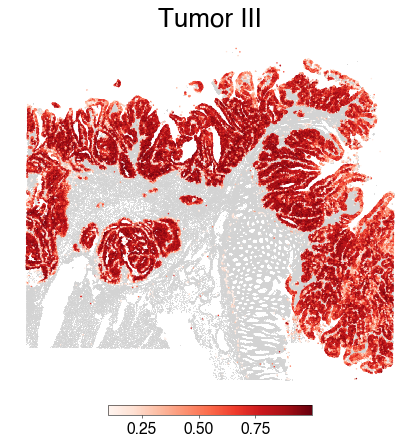

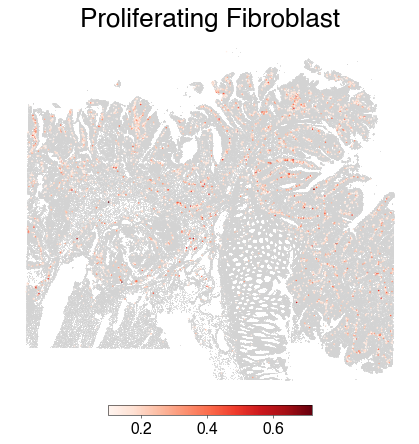

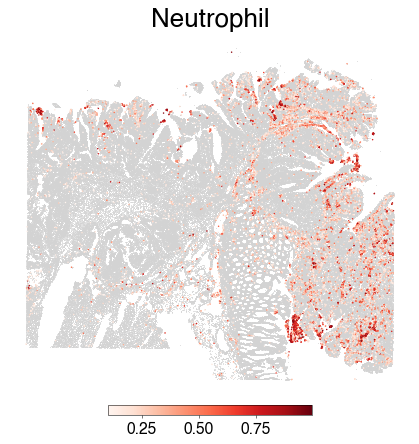

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Proliferating Fibroblast'
ct_list = ['Tumor III', 'Proliferating Fibroblast', 'Neutrophil']
for ct in ct_list:
    data = adata_xenium.obsm['proportion'][ct]
    prop = adata_xenium.obsm['proportion'][ct]
    fig, ax = plt.subplots(figsize=(7, 6.4))
    norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
    #two slope norm
    norm = TwoSlopeNorm(vcenter=0)
    mask = prop < 0.1
    sc_ignore = ax.scatter(
        -adata_xenium.obsm['spatial'][mask, 0],
        -adata_xenium.obsm['spatial'][mask, 1],
        c='lightgray',
        s=0.5,
        linewidths=0,
        #norm=norm
    )
    sc = ax.scatter(
        -adata_xenium.obsm['spatial'][~mask, 0],
        -adata_xenium.obsm['spatial'][~mask, 1],
        c=data[~mask],
        s=2,
        cmap='Reds',
        linewidths=0,
        #norm=norm
    )
    # cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    # cb.locator = MaxNLocator(nbins=5)
    # cb.update_ticks()
    # cb.ax.tick_params(labelsize=12)
    # #cb.set_label('Proportion', fontsize=12)
    cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    #cb.locator = MaxNLocator(nbins=1)
    #cb.update_ticks()
    cb.ax.tick_params(labelsize=15)
    #cb.set_label('Normalized score', fontsize=12)
    # no ticks
    #cb.set_ticks([])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    ax.set_title(ct, fontsize=25)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

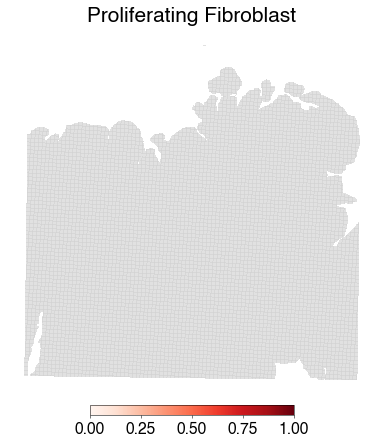

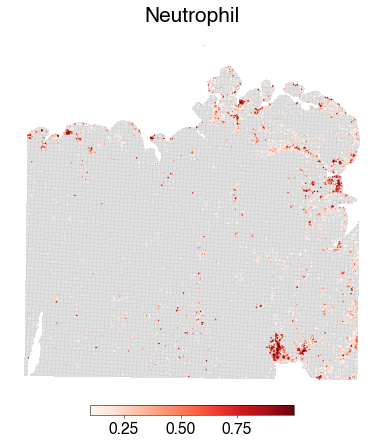

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

for ct in ct_list:
    data = adata_result.obsm['proportion'][ct]
    prop = adata_result.obsm['proportion'][ct]
    fig, ax = plt.subplots(figsize=(7, 6.4))
    norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
    #two slope norm
    norm = TwoSlopeNorm(vcenter=0)
    mask = prop < 0.1
    sc_ignore = ax.scatter(
        adata_result.obsm['spatial'][mask, 0],
        -adata_result.obsm['spatial'][mask, 1],
        c='lightgray',
        s=0.5,
        linewidths=0,
        #norm=norm
    )
    sc = ax.scatter(
        adata_result.obsm['spatial'][~mask, 0],
        -adata_result.obsm['spatial'][~mask, 1],
        c=data[~mask],
        s=2,
        cmap='Reds',
        linewidths=0,
        #norm=norm
    )
    # cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    # cb.locator = MaxNLocator(nbins=5)
    # cb.update_ticks()
    # cb.ax.tick_params(labelsize=12)
    # #cb.set_label('Proportion', fontsize=12)
    cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    #cb.locator = MaxNLocator(nbins=1)
    #cb.update_ticks()
    cb.ax.tick_params(labelsize=15)
    #cb.set_label('Normalized score', fontsize=12)
    # no ticks
    #cb.set_ticks([])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    ax.set_title(ct, fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

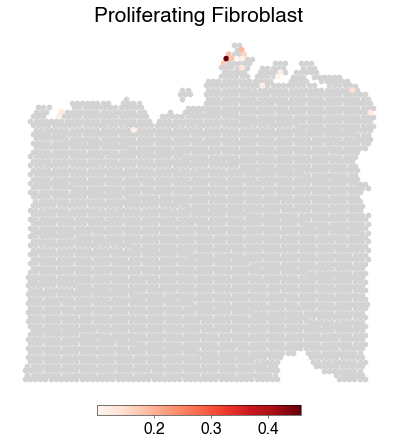

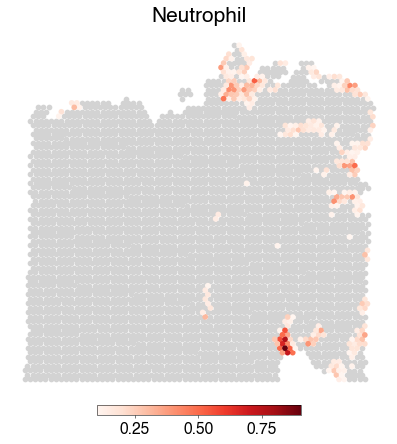

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

for ct in ct_list:
    data = adata_visium.obsm['proportion'][ct]
    prop = adata_visium.obsm['proportion'][ct]
    fig, ax = plt.subplots(figsize=(7, 6.4))
    norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
    #two slope norm
    norm = TwoSlopeNorm(vcenter=0)
    mask = prop < 0.1
    sc_ignore = ax.scatter(
        adata_visium.obsm['spatial'][mask, 0],
        -adata_visium.obsm['spatial'][mask, 1],
        c='lightgray',
        s=30,
        linewidths=0,
        #norm=norm
    )
    sc = ax.scatter(
        adata_visium.obsm['spatial'][~mask, 0],
        -adata_visium.obsm['spatial'][~mask, 1],
        c=data[~mask],
        s=30,
        cmap='Reds',
        linewidths=0,
        #norm=norm
    )
    # cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    # cb.locator = MaxNLocator(nbins=5)
    # cb.update_ticks()
    # cb.ax.tick_params(labelsize=12)
    # #cb.set_label('Proportion', fontsize=12)
    cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
    #cb.locator = MaxNLocator(nbins=1)
    #cb.update_ticks()
    cb.ax.tick_params(labelsize=15)
    #cb.set_label('Normalized score', fontsize=12)
    # no ticks
    #cb.set_ticks([])
    # 去掉边框
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    ax.set_title(ct, fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()